# 1. Setup 

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from category_encoders import OneHotEncoder
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import FunctionTransformer
import re
import optuna
import time
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pickle
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [7]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

In [8]:
# Define the path to the Excel file
data_path = "./finaccess2024_datasprint-2.xlsx"

# 2. 🧹 Data Wrangling Function: wrangle()

In [9]:
def wrangle(path):
    data = pd.read_excel(path)
    # Load the data
    return (
        data
        # Impute barriers_bank nulls (27.5% missing) with 'No barrier'
        .fillna("No barrier")
        # Replace 'Refused to Answer (DO NOT READ OUT)' , 'Other (Specify)', 95 and 'Don't know (DO NOT READ OUT)' in education_level column with 'Other'
        .assign(

            education_level=lambda x: (
                x["education_level"]
                .astype(str)

                # remove quotes (if any)
                .str.replace('"', '', regex=False)

                # strip outer spaces
                .str.strip()

                # Replace 'Refused to Answer (DO NOT READ OUT)' , 'Other (Specify)', 95 and 'Don't know (DO NOT READ OUT)' in education_level column with 'Other'
                .replace({
                    "Refused to Answer (DO NOT READ OUT)": "Other",
                    "Other (Specify)": "Other",
                    "95": "Other",
                    "Don't know (DO NOT READ OUT)": "Other"
                })

            ),
             # Replace 'Don't know   (DO NOT READ OUT)' and 'Refused to Answer(DO NOT READ OUT)' in marital_status column with 'Other'
            marital_status= lambda x: (
                x["marital_status"]
                .replace({
                    "Don't know   (DO NOT READ OUT)": "Other",
                    "Refused to Answer(DO NOT READ OUT)": "Other"
                })
            )
        )
    )

In [11]:
# Wrangle the data
cleaned_df = wrangle(data_path)
# verify the wrangling
print(f"Dimensions after wrangling: {cleaned_df.shape[0]} rows and {cleaned_df.shape[1]} columns.")
print(cleaned_df.info())
cleaned_df.head()


Dimensions after wrangling: 20871 rows and 28 columns.
<class 'pandas.DataFrame'>
RangeIndex: 20871 entries, 0 to 20870
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   county                 20871 non-null  str   
 1   location_type          20871 non-null  str   
 2   Sex                    20871 non-null  str   
 3   Age                    20871 non-null  str   
 4   household_size         20871 non-null  int64 
 5   education_level        20871 non-null  str   
 6   marital_status         20871 non-null  str   
 7   monthly_income         20871 non-null  int64 
 8   Savings_formal         20871 non-null  str   
 9   Savings_informal       20871 non-null  str   
 10  Loan_formal            20871 non-null  str   
 11  Loan_informal          20871 non-null  str   
 12  defaulted              20871 non-null  str   
 13  formal_service_use     20871 non-null  str   
 14  mobile_money_access    208

,county,location_type,Sex,Age,household_size,education_level,marital_status,monthly_income,Savings_formal,Savings_informal,Loan_formal,Loan_informal,defaulted,formal_service_use,mobile_money_access,barriers_mobile_money,mobile_ownership_1,experienced_shock,nfhi_11,nfhi_12,nfhi_13,accessto_13k_1month,not_difficult,financial_status,fl_score,prodsum1,barriers_bank,has_disability
0,Garissa,Urban,Female,26-35,5,Completed technical training after secondary school,Married/Living with partner,30000,Non-usage,Non-usage,Non-usage,Usage,No,Usage,Yes,0,Yes,No,Yes,Yes,Yes,Yes,No,Stayed the same,All correct,3,No barrier,Without Disability
1,Garissa,Urban,Female,Above 55,11,None,Married/Living with partner,10000,Non-usage,Non-usage,Non-usage,Non-usage,No,Usage,Yes,0,Yes,No,No,No,Yes,No,No,Worsened,Two correct,1,Affordability,Without Disability
2,Busia,Urban,Female,26-35,2,Primary completed,Divorced/separated,3000,Usage,Usage,Non-usage,Non-usage,No,Usage,Yes,0,Yes,Yes,Yes,No,No,No,No,Improved,All correct,5,Affordability,Without Disability
3,Kiambu,Urban,Male,18-25,1,Some secondary,Single/Never Married,10000,Usage,Non-usage,Usage,Usage,Yes,Usage,Yes,0,Yes,No,No,No,No,Yes,No,Improved,All correct,4,Affordability,Without Disability
4,Murang'a,Urban,Female,18-25,1,Some technical training after secondary school,Single/Never Married,10000,Usage,Non-usage,Usage,Non-usage,No,Usage,Yes,0,Yes,No,Yes,Yes,Yes,Yes,Yes,Improved,All correct,5,No barrier,Without Disability


In [12]:
# Check the value counts of the education_level and marital_status columns after wrangling
print("Education Level Value Counts:")
print(cleaned_df["education_level"].value_counts())
print("\n")
print("Marital Status Value Counts:")
cleaned_df["marital_status"].value_counts()

Education Level Value Counts:
education_level
Secondary completed                                    4113
Primary completed                                      3953
Some primary                                           3731
None                                                   3078
Some secondary                                         2731
Completed technical training after secondary school    1421
University completed                                    988
Some technical training after secondary school          501
Some university                                         346
Other                                                     9
Name: count, dtype: int64


Marital Status Value Counts:


marital_status
Married/Living with partner    11432
Single/Never Married            5770
Widowed                         2233
Divorced/separated              1427
Other                              9
Name: count, dtype: int64

In [13]:
# Descriptive Statistics of the cleaned data
cleaned_df.describe(include="all")

,county,location_type,Sex,Age,household_size,education_level,marital_status,monthly_income,Savings_formal,Savings_informal,Loan_formal,Loan_informal,defaulted,formal_service_use,mobile_money_access,barriers_mobile_money,mobile_ownership_1,experienced_shock,nfhi_11,nfhi_12,nfhi_13,accessto_13k_1month,not_difficult,financial_status,fl_score,prodsum1,barriers_bank,has_disability
count,20871,20871,20871,20871,20871.000000,20871,20871,20871.000000,20871,20871,20871,20871,20871,20871,20871,20871.0,20871,20871,20871,20871,20871,20871,20871,20871,20871,20871.000000,20871,20871
unique,47,2,2,6,NaN,10,5,NaN,2,2,2,2,2,2,2,10.0,2,2,2,2,2,2,2,3,4,NaN,10,2
top,Meru,Rural,Female,26-35,NaN,Secondary completed,Married/Living with partner,NaN,Non-usage,Non-usage,Non-usage,Non-usage,No,Usage,Yes,0.0,Yes,No,Yes,Yes,Yes,No,No,Worsened,Two correct,NaN,Affordability,Without Disability
freq,637,13549,12326,5361,NaN,4113,11432,NaN,11635,16031,12340,12604,13920,18224,17868,16409.0,16888,11785,10744,12887,13151,10630,16337,10981,8580,NaN,10223,19936
mean,NaN,NaN,NaN,NaN,4.215946,NaN,NaN,9702.774280,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.936563,NaN,NaN
std,NaN,NaN,NaN,NaN,2.512658,NaN,NaN,15423.366592,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.227992,NaN,NaN
min,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,100.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,2500.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,5000.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,6.000000,NaN,NaN,10000.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.000000,NaN,NaN


# 3. Univariate Analysis: Understanding One Variable at a Time

3.1 Univariate analysis for numeric variables

In [14]:
numeric_cols = cleaned_df.select_dtypes(include="number").columns
cleaned_df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
household_size,20871.0,4.215946,2.512658,1.0,2.0,4.0,6.0,20.0
monthly_income,20871.0,9702.774280,15423.366592,100.0,2500.0,5000.0,10000.0,200000.0
prodsum1,20871.0,3.936563,3.227992,0.0,1.0,3.0,6.0,22.0


 🔍Monthly Income Interpretation
- The mean is almost double the median, indicating a strong right-skewed distribution.
- Most individuals earn around 5,000–10,000, but a small group earns extremely high incomes.
- The maximum value (200,000) is a major outlier compared to the typical population.

⚠️ Insight
Income distribution is highly unequal, with a few high-income individuals pulling the average upward.
This is typical of financial datasets in developing economies.
Median is a more reliable measure than mean here.

🔍 Household Size iInterpretation
- The average household has ~4 people, which is typical for many Kenyan households.
- The median (4) is close to the mean → distribution is fairly balanced.
- However, the maximum value (20) is very high and suggests outliers or extended family households.

⚠️ Insight
Some households are significantly larger than the norm, which may indicate:
extended families,
data entry errors,
or shared housing arrangements

🔍 Financial Product Usage (prodsum1)Interpretation
- On average, individuals use about 4 financial products/services.
- The median (3) suggests most people use fewer products than the average.
- The maximum (22) indicates a small group with very high financial engagement.

⚠️ Insight
Distribution is moderately skewed to the right.
There is a clear divide between:
low financial inclusion users (0–3 products)
highly engaged users (10+ products)

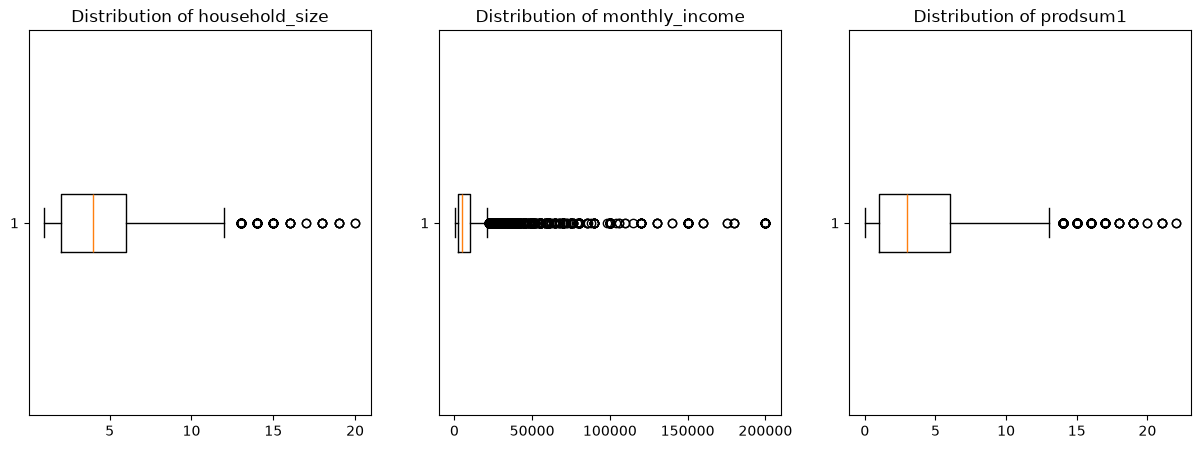

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax,col in zip(axes, numeric_cols):
    ax.boxplot(cleaned_df[col],vert=False)
    ax.set_title(f"Distribution of {col}")

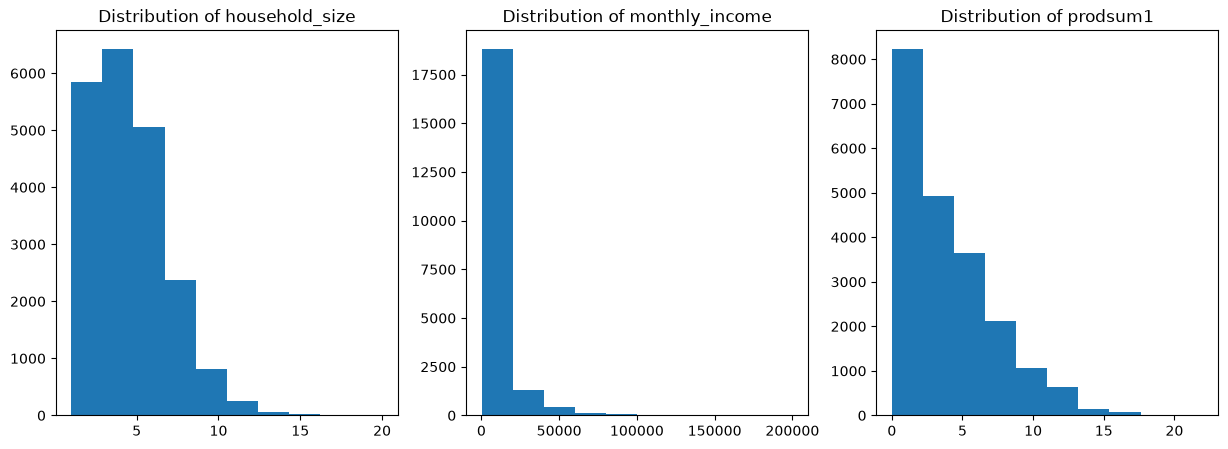

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax,col in zip(axes, numeric_cols):
    ax.hist(cleaned_df[col])
    ax.set_title(f"Distribution of {col}")

3.2 Univariate analysis for non-numeric variables

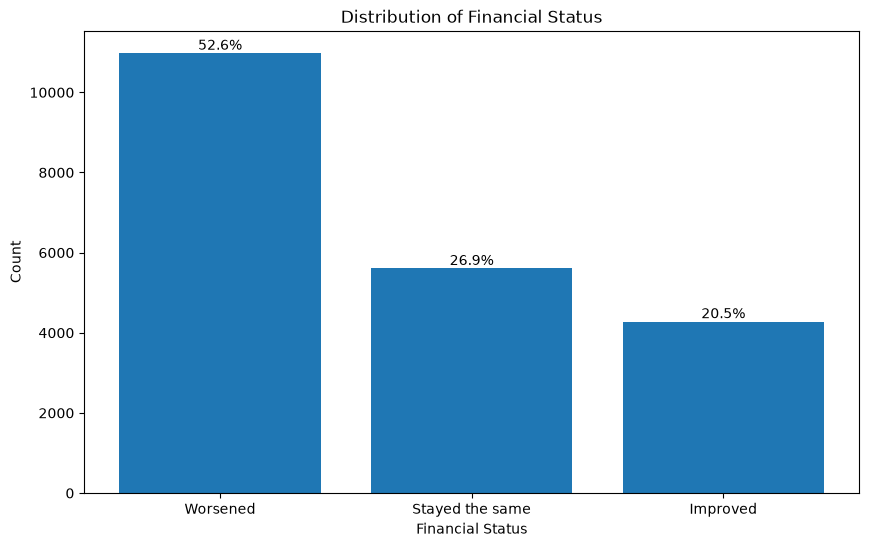

In [17]:
counts = cleaned_df["financial_status"].value_counts()
percentages = cleaned_df["financial_status"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(10,6))

bars = ax.bar(counts.index, counts.values)

ax.set_xlabel("Financial Status")
ax.set_ylabel("Count")
ax.set_title("Distribution of Financial Status")

for bar, pct in zip(bars, percentages):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center",
        va="bottom"
    )

plt.show()

Financial Status Distribution

- The financial status of respondents shows a clear skew toward negative outcomes. A majority of individuals (52.6%) report that their financial situation has worsened, while 26.9% report no change. Only 20.5% experienced an improvement in their financial status.

- This suggests that financial decline is the most common outcome in the dataset, indicating potential exposure to economic shocks and limited upward financial mobility among respondents.

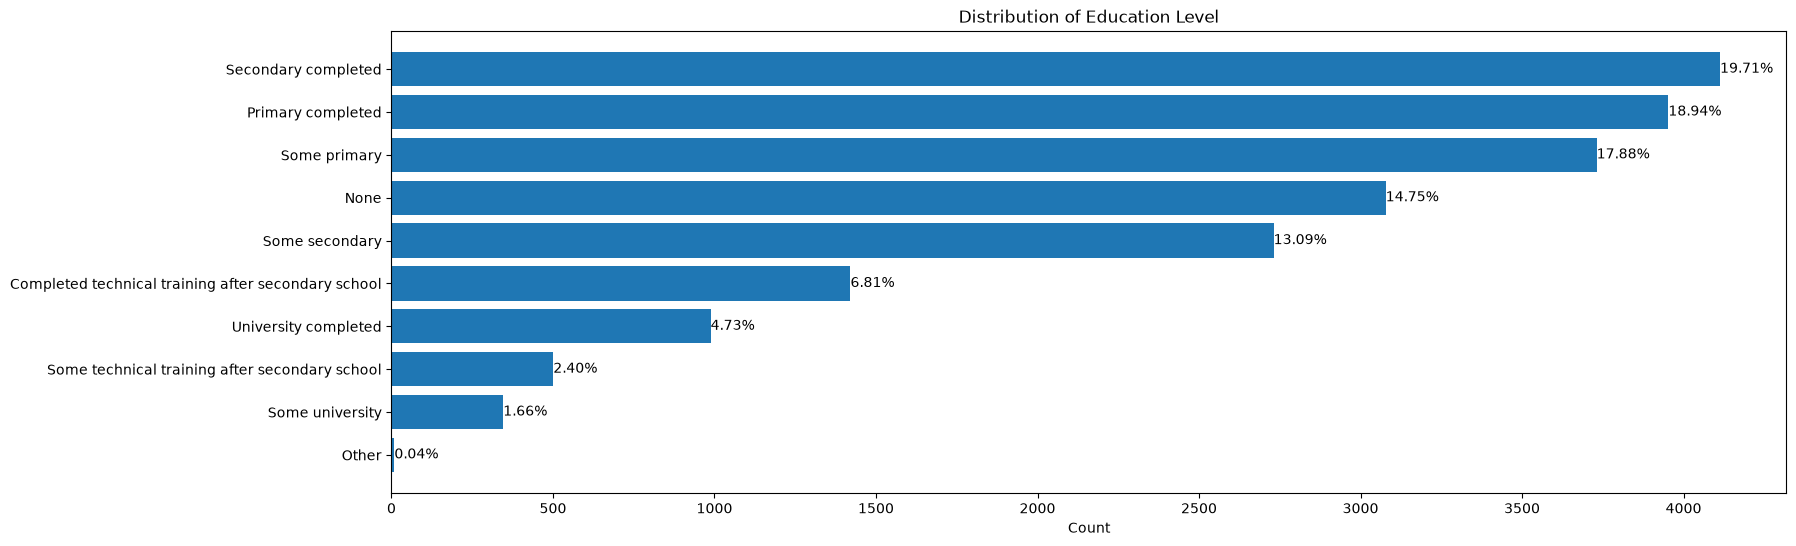

In [18]:
counts = cleaned_df["education_level"].value_counts().sort_values(ascending=True)
percentages = cleaned_df["education_level"].value_counts(normalize=True).loc[counts.index] * 100

fig, ax = plt.subplots(figsize=(18,6))

bars = ax.barh(counts.index, counts.values)

ax.set_xlabel("Count")
ax.set_title("Distribution of Education Level")
for bar, pct in zip(bars, percentages):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f"{pct:.2f}%",
        va="center"
    )

plt.show()

📊 Education Level Distribution (Summary)

Most respondents have primary or secondary education, with Secondary completed (19.7%), Primary completed (18.9%), and Some primary (17.9%) forming the largest groups. A notable 14.7% have no formal education.

Higher education levels are less common, with university completed (4.7%) and technical training (6.8%) representing a small share of the population. The “Other” category is negligible (0.04%).

🔍 Key Insight

The population is largely concentrated in lower to mid-level education, with limited tertiary education attainment.

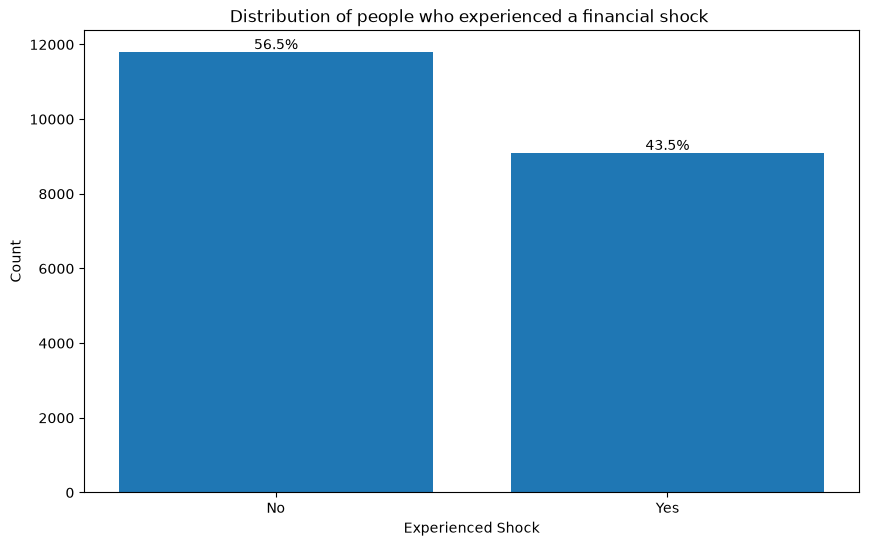

In [19]:
counts = cleaned_df["experienced_shock"].value_counts()
percentages = cleaned_df["experienced_shock"].value_counts(normalize=True) * 100

fig,ax = plt.subplots(figsize=(10,6))
bars = ax.bar(counts.index, counts.values)
ax.set_xlabel("Experienced Shock")
ax.set_ylabel("Count")
ax.set_title("Distribution of people who experienced a financial shock ")
for bar, pct in zip(bars, percentages):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center",
        va="bottom"
    )

⚡ Experienced Financial Shock (Summary)

The dataset shows that 43.5% of respondents have experienced a financial shock, while 56.5% have not.

🔍 Key Insight

A significant portion of the population has been exposed to financial shocks, indicating a relatively high level of economic vulnerability. This variable is likely an important driver of financial outcomes in subsequent analysis.

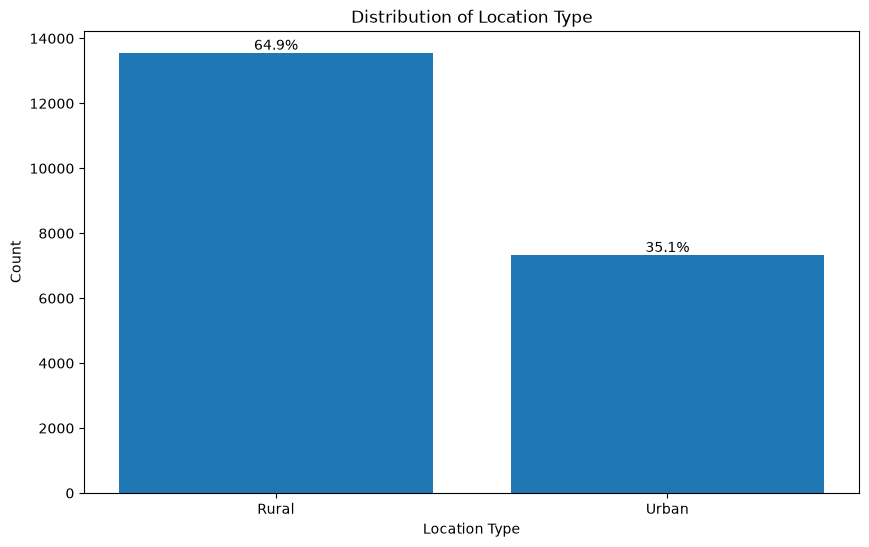

In [20]:
counts = cleaned_df["location_type"].value_counts()
percentages = cleaned_df["location_type"].value_counts(normalize=True) * 100
fig, ax = plt.subplots(figsize=(10,6))
bars = ax.bar(counts.index, counts.values)
ax.set_xlabel("Location Type")
ax.set_ylabel("Count")
ax.set_title("Distribution of Location Type")
for bar, pct in zip(bars, percentages):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center",
        va="bottom"
    )

Location Type (Summary)

The majority of respondents are based in rural areas (64.9%), while 35.1% are urban residents.

🔍 Key Insight

The dataset is predominantly rural, suggesting that any financial trends or outcomes observed are largely driven by rural populations. This may have important implications for access to services, financial inclusion, and vulnerability to economic shocks.

# 4. Bivariate Analysis 

4.1 Financial Status by Experienced Shock

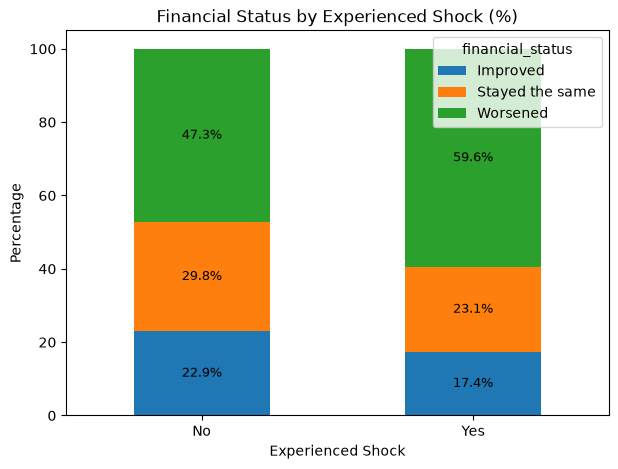

In [21]:
shock_table = (
    cleaned_df
    .groupby("experienced_shock")["financial_status"]
    .value_counts(normalize=True)
    .unstack() * 100
)

fig, ax = plt.subplots(figsize=(7,5))

shock_table.plot(kind="bar", stacked=True, ax=ax)

ax.set_title("Financial Status by Experienced Shock (%)")
ax.set_ylabel("Percentage")
ax.set_xlabel("Experienced Shock")
plt.xticks(rotation=0)

for i, shock in enumerate(shock_table.index):
    bottom = 0  

    for status in shock_table.columns:
        value = shock_table.loc[shock, status]

        if value > 0:  
            ax.text(
                i,                      
                bottom + value / 2,     
                f"{value:.1f}%",
                ha="center",
                va="center",
                fontsize=9
            )

            bottom += value  

plt.show()

⚡ Financial Status by Experienced Shock (Summary)
- The data shows a clear relationship between experiencing a financial shock and poorer financial outcomes.
- Among respondents who did not experience a shock, a smaller share report worsening financial status (47.3%), compared to those who experienced a shock, where the proportion of respondents with worsened financial status rises to 59.6%.
- Conversely, respondents with no shocks are more likely to report stable or improved outcomes compared to those who experienced shocks.

🔍 Key Insight
Experiencing a financial shock is strongly associated with worse financial outcomes, suggesting that shocks are a major driver of financial vulnerability in the dataset.

4.2 Financial Status by Education Level 

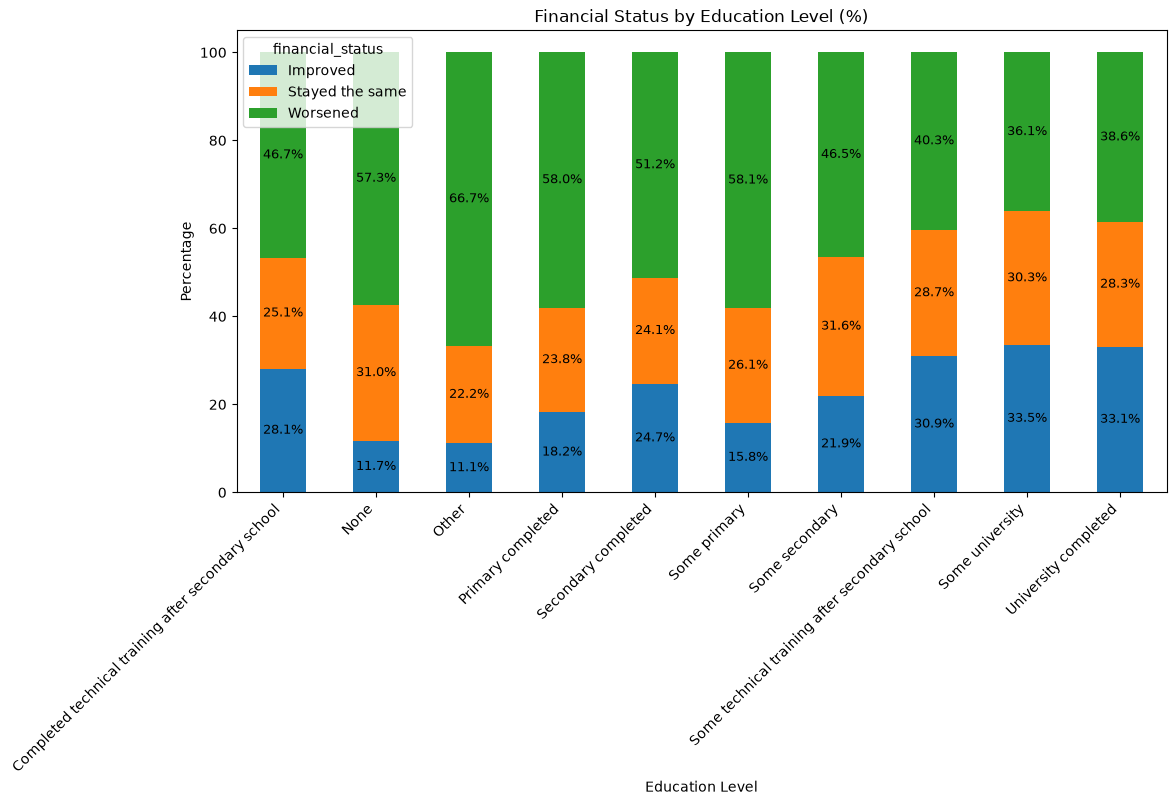

In [22]:
edu_table = (
    cleaned_df
    .groupby("education_level")["financial_status"]
    .value_counts(normalize=True)
    .unstack() * 100
)
fig, ax = plt.subplots(figsize=(12,6))
edu_table.plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Financial Status by Education Level (%)")
ax.set_ylabel("Percentage")
ax.set_xlabel("Education Level")
plt.xticks(rotation=45, ha="right")

for i, edu in enumerate(edu_table.index):
    bottom = 0  

    for status in edu_table.columns:
        value = edu_table.loc[edu, status]

        if value > 0:  
            ax.text(
                i,                      
                bottom + value / 2,     
                f"{value:.1f}%",
                ha="center",
                va="center",
                fontsize=9
            )

            bottom += value

🎓 Financial Status by Education Level (Summary)

- There is a clear relationship between education level and financial outcomes in the dataset.

- Respondents with higher education levels, such as university completed (33.1% improved, 38.6% worsened) and some university (33.5% improved, 36.1% worsened), tend to report better financial outcomes and lower rates of financial decline compared to those with lower education levels.

- In contrast, individuals with no formal education (57.3% worsened) and primary completed (58.0% worsened) show significantly higher proportions of financial deterioration.

🔍 Key Insight

Higher education is associated with better financial resilience, while lower education levels are linked to a greater likelihood of financial decline.

4.3 Financial Status by Location type 

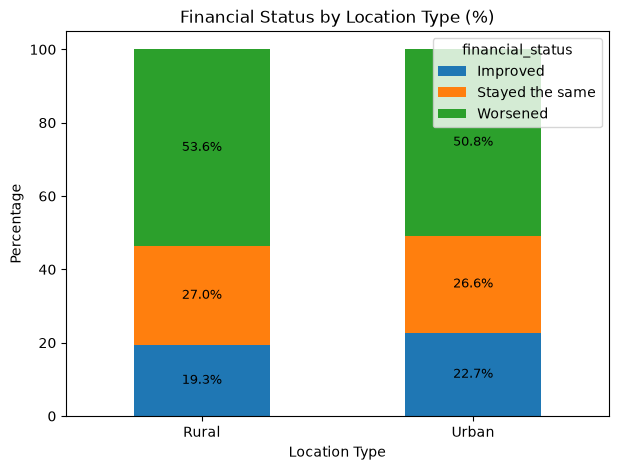

In [23]:
loc_table = (
    cleaned_df
    .groupby("location_type")["financial_status"]
    .value_counts(normalize=True)
    .unstack() * 100
)
fig, ax = plt.subplots(figsize=(7,5))
loc_table.plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Financial Status by Location Type (%)")
ax.set_ylabel("Percentage")
ax.set_xlabel("Location Type")
plt.xticks(rotation=0)
for i, loc in enumerate(loc_table.index):
    bottom = 0  
    for status in loc_table.columns:
        value = loc_table.loc[loc, status]
        if value > 0:  
            ax.text(
                i,                      
                bottom + value / 2,     
                f"{value:.1f}%",
                ha="center",
                va="center",
                fontsize=9
            )
            bottom += value

🌍 Financial Status by Location Type (Summary)
- The distribution shows differences in financial outcomes between rural and urban respondents.
- Rural residents report a higher proportion of worsened financial status (53.6%) compared to urban residents (50.8%). Urban respondents, however, have slightly higher rates of improvement (22.7% vs 19.3%).

🔍 Key Insight
Urban respondents appear to have slightly better financial resilience, with lower levels of financial decline and marginally higher improvement rates compared to rural respondents.

4.4 Financial Status by Monthly income 

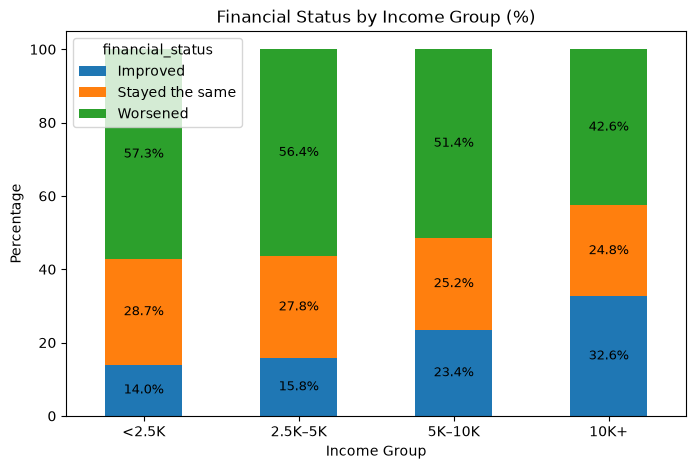

In [24]:
cleaned_df["income_group"] = pd.cut(
    cleaned_df["monthly_income"],
    bins=[0, 2500, 5000, 10000, float("inf")],
    labels=["<2.5K", "2.5K–5K", "5K–10K", "10K+"]
)
income_table = (
    cleaned_df
    .groupby("income_group")["financial_status"]
    .value_counts(normalize=True)
    .unstack() * 100
)
fig, ax = plt.subplots(figsize=(8,5))

income_table.plot(kind="bar", stacked=True, ax=ax)

ax.set_title("Financial Status by Income Group (%)")
ax.set_ylabel("Percentage")
ax.set_xlabel("Income Group")
plt.xticks(rotation=0)


for i, loc in enumerate(income_table.index):
    bottom = 0

    for status in income_table.columns:
        value = income_table.loc[loc, status]

        if value > 0:
            ax.text(
                i,
                bottom + value / 2,
                f"{value:.1f}%",  
                ha="center",
                va="center",
                fontsize=9
            )

            bottom += value

plt.show()

💰 Financial Status by Income Group (Summary)

- There is a clear income gradient in financial outcomes. Respondents in the lowest income group (<2.5K) report the highest financial decline (57.3% worsened) and the lowest improvement (14.0%).
- As income increases, financial outcomes improve steadily. In the highest income group (10K+), the proportion reporting worsened financial status drops to 42.6%, while improvement rises to 32.6%.

🔍 Key Insight
Higher income is strongly associated with better financial resilience, with a clear transition from high vulnerability at low income levels to greater stability and improvement at higher income levels.

# 5. Binary Encoding

In [25]:
# Binary categorical columns (2 unique values)
binary_cols = [col for col in cleaned_df.columns if cleaned_df[col].nunique() == 2]
# Map binary categorical columns to 0 and 1
cleaned_df[binary_cols] = cleaned_df[binary_cols].replace({
    'Urban': 1, 'Rural': 0,
    'Male': 1, 'Female': 0,
    'Usage': 1, 'Non-usage': 0,
    'Yes': 1, 'No': 0,
    'With Disability': 1, 'Without Disability': 0
})

cleaned_df[binary_cols] = cleaned_df[binary_cols].astype("int64")

# 6. Multicollinearity Analysis

In [26]:
#  Drop target 
X_vif = cleaned_df.drop(columns=["financial_status"], errors="ignore")

# Force ALL categorical columns to numeric via one-hot encoding
X_vif = pd.get_dummies(X_vif, drop_first=True)

print(X_vif.dtypes.value_counts())  # must be ONLY int/float

# Convert to float matrix
X_matrix = X_vif.astype(float).values

# 8. Compute VIF
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns

vif_data["VIF"] = [
    variance_inflation_factor(X_matrix, i)
    for i in range(X_matrix.shape[1])
]

vif_data.sort_values(by="VIF", ascending=False)

bool     88
int64    20
Name: count, dtype: int64


,feature,VIF
10,mobile_money_access,66.202017
9,formal_service_use,64.661226
18,prodsum1,13.403323
11,mobile_ownership_1,13.127810
96,barriers_bank_Affordability,10.663043
67,Age_26-35,9.707996
80,marital_status_Married/Living with partner,8.964588
70,Age_Above 55,8.370250
68,Age_36-45,7.710558
100,barriers_bank_No barrier,7.610594


📊 VIF / Multicollinearity Summary

- VIF analysis shows that most features have low to moderate multicollinearity (VIF < 5), indicating generally stable relationships across predictors. 
- However, a few variables—especially mobile_money_access (~66) and formal_service_use (~65)—exhibit high multicollinearity, suggesting overlapping information.

- No features were dropped, as the chosen models (Random Forest, XGBoost, LightGBM) are tree-based and robust to multicollinearity. 
- Therefore, all variables were retained to preserve predictive signal.

# 7. Machine learning

###  Creating the Feature Matrix and Target Vector

In [27]:
target = "financial_status"
Features = [col for col in cleaned_df.columns if col not in [target]]
X = cleaned_df[Features]
y = cleaned_df[target]
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Feature columns: {X.columns.tolist()}")

Features shape: (20871, 28)
Target shape: (20871,)
Feature columns: ['county', 'location_type', 'Sex', 'Age', 'household_size', 'education_level', 'marital_status', 'monthly_income', 'Savings_formal', 'Savings_informal', 'Loan_formal', 'Loan_informal', 'defaulted', 'formal_service_use', 'mobile_money_access', 'barriers_mobile_money', 'mobile_ownership_1', 'experienced_shock', 'nfhi_11', 'nfhi_12', 'nfhi_13', 'accessto_13k_1month', 'not_difficult', 'fl_score', 'prodsum1', 'barriers_bank', 'has_disability', 'income_group']


In [28]:
y.value_counts()

financial_status
Worsened           10981
Stayed the same     5609
Improved            4281
Name: count, dtype: int64

### Train-test split

In [29]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Split train further into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42, stratify= y_train
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 12522 samples
Validation set: 4174 samples
Test set: 4175 samples


## RandomForest Classifier

In [30]:
rf = make_pipeline(
   OneHotEncoder(use_cat_names=True),  
   StandardScaler(with_mean=False),   
   RandomForestClassifier(n_estimators=300,class_weight='balanced',random_state=42, n_jobs=-1)
)
# Training timer
start_train = time.time()
rf.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

# Prediction timer
start_pred = time.time()
val_pred = rf.predict(X_val)
pred_time = time.time() - start_pred
print(f"⏱ Prediction time: {pred_time:.4f} seconds")

# Classification report
print(classification_report(y_val, val_pred, digits=3))

⏱ Training time: 0.95 seconds
⏱ Prediction time: 0.0835 seconds
                 precision    recall  f1-score   support

       Improved      0.414     0.414     0.414       856
Stayed the same      0.444     0.361     0.398      1122
       Worsened      0.643     0.704     0.672      2196

       accuracy                          0.552      4174
      macro avg      0.500     0.493     0.495      4174
   weighted avg      0.542     0.552     0.546      4174



📋 Random Forest Report 

- The Random Forest model achieves a Weighted F1-score of 0.546, making it the best-performing model overall. 
- It demonstrates strong predictive ability for the majority class (Worsened, F1: 0.672), while performance on the minority classes (“Improved” and “Stayed the same”) remains moderate. 
- This indicates that the model is strongly influenced by the underlying class distribution, performing best where data density is highest. Despite this, it provides the most stable and reliable overall performance among all tested models.

## LightGBM classifier

In [31]:
lgbm = make_pipeline(
   OneHotEncoder(use_cat_names=True),   
   LGBMClassifier(n_estimators=500, learning_rate=0.05, class_weight='balanced', random_state=42, n_jobs=-1)
)
# Training time
start_train = time.time()
lgbm.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

# Prediction timer
start_pred = time.time()
val_pred = lgbm.predict(X_val)
pred_time = time.time() - start_pred
print(f"⏱ Prediction time: {pred_time:.4f} seconds")

# Classification report
print(classification_report(y_val, val_pred, digits=3))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001490 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 382
[LightGBM] [Info] Number of data points in the train set: 12522, number of used features: 110
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
⏱ Training time: 5.80 seconds
⏱ Prediction time: 0.0966 seconds
                 precision    recall  f1-score   support

       Improved      0.376     0.486     0.424       856
Stayed the same      0.402     0.404     0.403      1122
       Worsened      0.677     0.598     0.635      2196

       accuracy                          0.523      4174
      macro avg      0.485     0.496     0.487      41

📋 LightGBM Report 

- The LightGBM model achieves a Weighted F1-score of 0.529, which is lower than both Random Forest and XGBoost. 
- It shows improved balance across classes, with relatively better recall for the minority class (“Improved”, F1: 0.424), suggesting that the model is more sensitive to underrepresented outcomes. 
- However, this improvement comes at the cost of reduced performance on the majority class, leading to a lower overall weighted F1-score. As a result, LightGBM provides better class balance but weaker overall predictive strength.

## XGBoost Classifier

In [32]:
#  Map string labels to integers (0, 1, 2)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)

# Compute sample weights using the numeric target to address class imbalance
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train_encoded
)

#  Helper function to strip out [, ], and < from feature names
def clean_feature_names(X):
    if isinstance(X, pd.DataFrame):
        # Replace [, ], and < with an underscore or text equivalent
        new_cols = [re.sub(r'[\[\]<]', '_', str(col)) for col in X.columns]
        X.columns = new_cols
    return X

xgb = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    FunctionTransformer(clean_feature_names, validate=False),
    XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        eval_metric="mlogloss"
    )
)

# 4. Training time
start_train = time.time()
xgb.fit(X_train, y_train_encoded, xgbclassifier__sample_weight=sample_weights)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

# 5. Prediction timer
start_pred = time.time()
val_pred = xgb.predict(X_val)  
pred_time = time.time() - start_pred
print(f"⏱ Prediction time: {pred_time:.4f} seconds")

# 6. Classification report
print(classification_report(y_val_encoded, val_pred, target_names=le.classes_, digits=3))

⏱ Training time: 2.91 seconds
⏱ Prediction time: 0.0269 seconds
                 precision    recall  f1-score   support

       Improved      0.375     0.495     0.427       856
Stayed the same      0.426     0.406     0.416      1122
       Worsened      0.682     0.613     0.646      2196

       accuracy                          0.533      4174
      macro avg      0.494     0.505     0.496      4174
   weighted avg      0.550     0.533     0.539      4174



📋 XGBoost Report 

- The XGBoost model achieves a Weighted F1-score of 0.539, placing it between Random Forest and LightGBM in terms of overall performance. 
- It delivers a balanced trade-off between class performance, improving recall for the minority class (“Improved”, F1: 0.427) while maintaining competitive performance on the majority class (“Worsened”, F1: 0.646). 
- Although it does not surpass Random Forest on the primary metric, it demonstrates strong generalization and more balanced behavior across classes compared to a purely majority-driven model.

# Final Model Decision

- Based on the evaluation using the Weighted F1-score (primary metric), the Random Forest model is selected as the final model. 
- It achieves the highest overall performance (Weighted F1 = 0.546) while maintaining stable and consistent results across all classes.
- Although XGBoost and LightGBM provide more balanced class-level behavior, neither model improves upon the primary metric. 
- Therefore, Random Forest offers the best overall trade-off between predictive performance, stability, and computational efficiency, making it the most suitable model for this problem under the defined evaluation criteria.

## Hyperparameter Tuning  for RandomForest

In [33]:
def objective_rf(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 800),
        "max_depth": trial.suggest_int("max_depth", 5, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "max_features": trial.suggest_float("max_features", 0.3, 0.9),
        "class_weight": "balanced",
        "random_state": 42,
        "n_jobs": -1
    }



    pipeline = make_pipeline(
        OneHotEncoder(use_cat_names=True),
        StandardScaler(with_mean=False),  
        RandomForestClassifier(**params)
    )

    pipeline.fit(X_train, y_train)

    val_preds = pipeline.predict(X_val)

    return f1_score(y_val, val_preds, average="weighted")


# Run study
study_rf = optuna.create_study(direction="maximize")
study_rf.optimize(objective_rf, n_trials=30)

print("🏆 Best Random Forest Weighted F1-Score:", study_rf.best_value)
print("⚙️ Best Random Forest Params:", study_rf.best_params)

[I 2026-06-16 09:49:53,063] A new study created in memory with name: no-name-f305e13f-f164-4613-87b1-575f34b51ba0
[I 2026-06-16 09:49:57,088] Trial 0 finished with value: 0.5179486704812234 and parameters: {'n_estimators': 763, 'max_depth': 10, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 0.6986099647226557}. Best is trial 0 with value: 0.5179486704812234.
[I 2026-06-16 09:49:59,894] Trial 1 finished with value: 0.5161972370505183 and parameters: {'n_estimators': 492, 'max_depth': 25, 'min_samples_split': 15, 'min_samples_leaf': 14, 'max_features': 0.7076903870991922}. Best is trial 0 with value: 0.5179486704812234.
[I 2026-06-16 09:50:02,183] Trial 2 finished with value: 0.5088815069485264 and parameters: {'n_estimators': 758, 'max_depth': 8, 'min_samples_split': 13, 'min_samples_leaf': 4, 'max_features': 0.4297364645218699}. Best is trial 0 with value: 0.5179486704812234.
[I 2026-06-16 09:50:03,744] Trial 3 finished with value: 0.5142180001699885 and parameters: {'

🏆 Best Random Forest Weighted F1-Score: 0.5337455569349103
⚙️ Best Random Forest Params: {'n_estimators': 584, 'max_depth': 19, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': 0.5115641103426078}


Hyperparameter tuning of the Random Forest model using Optuna resulted in a best Weighted F1-score of 0.533, which is slightly lower than the baseline performance (0.546). Across trials, performance showed limited variation, indicating that changes in model configuration have minimal impact on predictive performance. This suggests that the Random Forest model has reached a performance plateau 

## Final Model Evaluation on Test Data (Random Forest)

In [34]:
final_rf_model = make_pipeline(
   OneHotEncoder(use_cat_names=True), 
   StandardScaler(with_mean=False),    
   RandomForestClassifier(n_estimators=300,class_weight='balanced',random_state=42, n_jobs=-1)
)
# Training timer
start_train = time.time()
final_rf_model.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

# Prediction timer
start_pred = time.time()
y_pred = final_rf_model.predict(X_test)
pred_time = time.time() - start_pred
print(f"⏱ Prediction time: {pred_time:.4f} seconds")

# Classification report
print("\n 📊 CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, digits=3))
print("=" * 65)


⏱ Training time: 0.94 seconds
⏱ Prediction time: 0.0751 seconds

 📊 CLASSIFICATION REPORT:
                 precision    recall  f1-score   support

       Improved      0.405     0.416     0.410       856
Stayed the same      0.406     0.309     0.351      1122
       Worsened      0.650     0.722     0.684      2197

       accuracy                          0.548      4175
      macro avg      0.487     0.482     0.482      4175
   weighted avg      0.534     0.548     0.538      4175



📋 Random Forest — Test Performance Summary

- The Random Forest model achieves a Weighted F1-score of 0.538 on the test set with an accuracy of 0.548. 
- It shows strong performance on the majority class (Worsened, F1 = 0.684), but significantly weaker performance on the Stayed the same class (F1 = 0.351). 
- Overall, the model is stable and slightly favors the majority class, leading to reasonable but unbalanced predictive performance across classes.

## Confusion Matrix

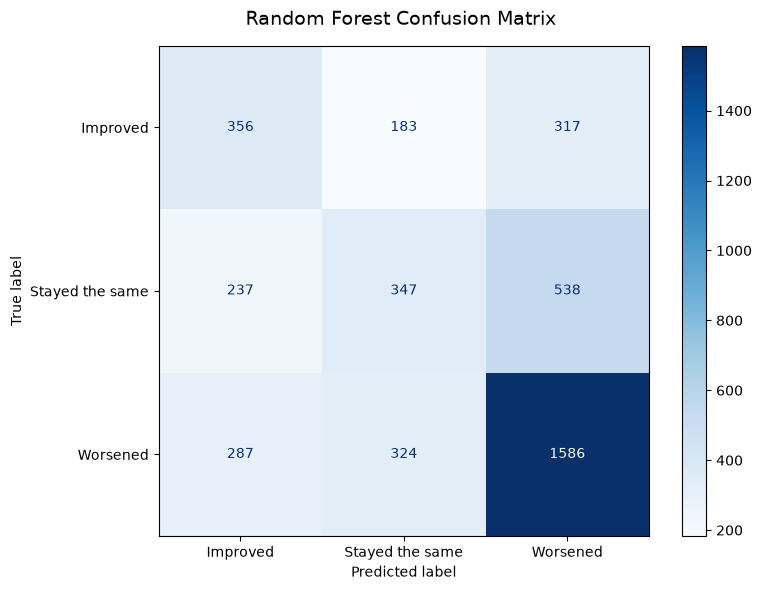

In [35]:
# Calculate and plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=final_rf_model.classes_)

# Create the visual plot
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=final_rf_model.classes_)

# Plot with a nice color map (Blues, Viridis, or Plasma work well)
disp.plot(cmap="Blues", ax=ax, values_format="d") 

plt.title("Random Forest Confusion Matrix ", fontsize=14, pad=15)
plt.grid(False) 
plt.tight_layout()
plt.show()

 📊 Confusion Matrix Interpretation (Random Forest)



### 🟢 Improved

Out of **856** actual “Improved” cases:

* **356** were correctly classified
* **183** were misclassified as “Stayed the same”
* **317** were misclassified as “Worsened”

👉 The model struggles to clearly separate “Improved” from the other classes, particularly confusing it with “Worsened”.

---

### 🟡 Stayed the same

Out of **1,122** actual “Stayed the same” cases:

* **347** were correctly classified
* **237** were predicted as “Improved”
* **538** were predicted as “Worsened”

👉 This is the weakest class performance, with a strong tendency to be misclassified as “Worsened”.

---

### 🔴 Worsened

Out of **2,197** actual “Worsened” cases:

* **1,586** were correctly classified
* **287** were misclassified as “Improved”
* **324** were misclassified as “Stayed the same”

👉 This class is predicted most accurately, indicating the model is strongest at identifying the dominant class.

---

## 📌 Key Insights

* The model performs best on the **“Worsened”** class due to its higher representation in the data.
* Most misclassifications occur between **“Stayed the same” and “Worsened”**, indicating overlap in feature patterns.
* “Improved” is moderately captured but still frequently confused with both other classes.



## RF Feature Importance

In [36]:
rf_encoder = final_rf_model.named_steps['onehotencoder']
rf_model = final_rf_model.named_steps['randomforestclassifier']
rf_feature_names = rf_encoder.get_feature_names_out()

In [37]:
importances = rf_model.feature_importances_ *100
rf_importances = pd.Series(importances, index=rf_feature_names).sort_values(ascending=False)
rf_top_15 = rf_importances.head(15)
rf_top_15

monthly_income                 7.175163
household_size                 6.200234
prodsum1                       5.488166
Sex                            2.131651
nfhi_11                        2.041808
location_type                  1.955453
experienced_shock              1.934175
Loan_informal                  1.851218
fl_score_Two correct           1.838670
nfhi_12                        1.836376
accessto_13k_1month            1.830296
nfhi_13                        1.797425
fl_score_All correct           1.734493
defaulted                      1.701770
barriers_bank_Affordability    1.558801
dtype: float64

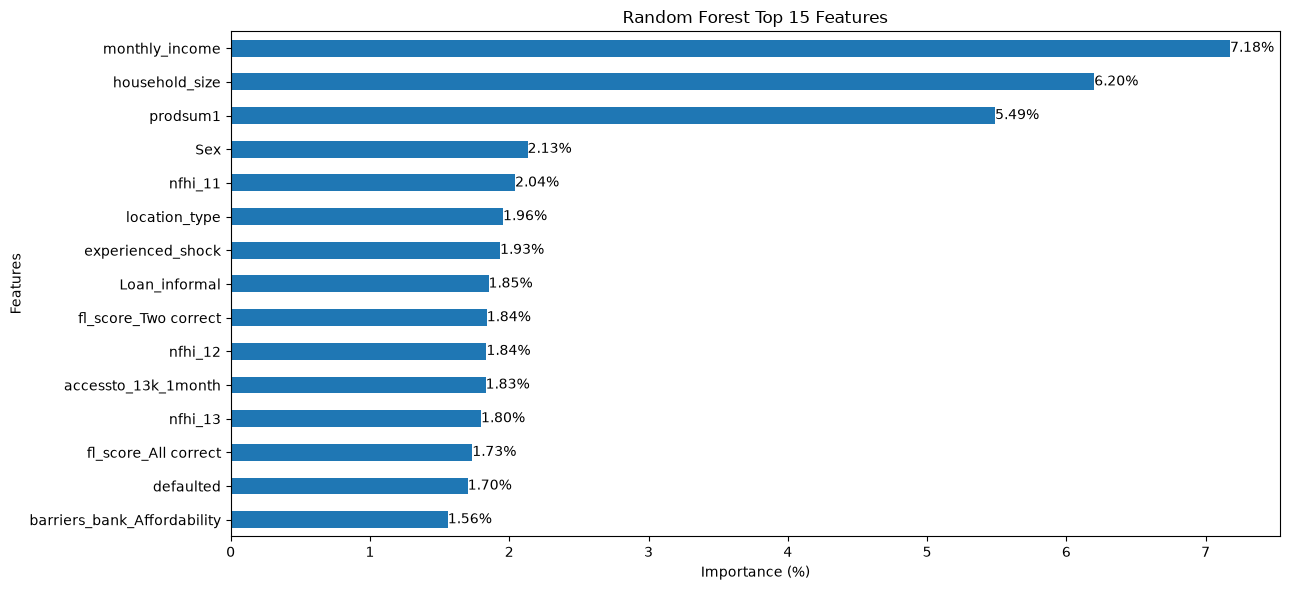

In [38]:
fig, ax = plt.subplots(figsize=(13,6))

bars = rf_top_15.plot(kind="barh", ax=ax)
ax.invert_yaxis()

ax.set_title("Random Forest Top 15 Features")
ax.set_xlabel("Importance (%)")
ax.set_ylabel("Features")

for i, value in enumerate(rf_top_15):
    ax.text(
        value,    
        i,                
        f"{value:.2f}%", 
        va="center"
    )

plt.tight_layout()
plt.show()

## RF Feature Importance Analysis

- The RF model identifies monthly income as the most influential predictor of financial status, contributing approximately 7.2% of the total feature importance. 
- This is followed by household size (6.2%) and prodsum1 (5.5%), indicating that income levels, household characteristics, and product ownership/access play a significant role in determining a household's financial outcome. 
- Other important factors include financial health indicators (nfhi_11, nfhi_12, nfhi_13), access to funds (accessto_13k_1month), financial literacy scores, informal borrowing, and affordability barriers to banking services.


In [39]:
path = '/Users/oronje/Desktop/Data_Sprint_2026/models'
def save_model(model, model_filepath):

    with open(model_filepath, 'wb') as file:

        pickle.dump(model, file)

save_model(final_rf_model,path+'/rf_model.pkl')

In [40]:
path = '/Users/oronje/Desktop/Data_Sprint_2026/models'
model_path_ = path+'/rf_model.pkl'

with open(model_path_, 'rb') as f:

    xgb_model = pickle.load(f)